In [ ]:
!nvidia-smi -L || echo "No GPU found"


GPU 0: Tesla T4 (UUID: GPU-39f75a32-3d6b-0caa-9cdb-1b1d5929b2fc)


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

# 👉 update ONLY these two if your paths differ
ZIP_PATH  = "/content/drive/MyDrive/OTML_CT-1/archive.zip"     # your ZIP
BASE_DIR  = "/content/drive/MyDrive/OTML_CT-1/eurosat_experiments"     # where outputs go

# working dirs (local, fast)
RAW_EXTRACT_DIR = "/content/eurosat_raw"   # temporary unzip here
DATA_DIR        = "/content/drive/MyDrive/OTML_CT-1/EuroSAT_RGB"   # final ImageFolder root (10 class folders)

import os
os.makedirs(BASE_DIR, exist_ok=True)
os.makedirs(RAW_EXTRACT_DIR, exist_ok=True)



Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
os.makedirs(DATA_DIR, exist_ok=True)

In [ ]:
import zipfile, os, shutil

# clean previous runs (safe to re-run)
if os.path.exists(RAW_EXTRACT_DIR):
    shutil.rmtree(RAW_EXTRACT_DIR)
os.makedirs(RAW_EXTRACT_DIR, exist_ok=True)

with zipfile.ZipFile(ZIP_PATH, 'r') as zf:
    zf.extractall(RAW_EXTRACT_DIR)

print("✅ Unzipped to:", RAW_EXTRACT_DIR)


✅ Unzipped to: /content/eurosat_raw


In [ ]:
import os, shutil
from glob import glob
from collections import Counter

# helper: count classes and print
def summarize(root):
    img_exts = ('.jpg','.jpeg','.png','.tif','.tiff','.bmp')
    all_imgs = []
    for dp, dn, files in os.walk(root):
        for f in files:
            if f.lower().endswith(img_exts):
                all_imgs.append(os.path.join(dp,f))
    print(f"Found {len(all_imgs)} images under: {root}")
    return all_imgs

# if DATA_DIR exists from a previous run, recreate it
if os.path.exists(DATA_DIR):
    shutil.rmtree(DATA_DIR)
os.makedirs(DATA_DIR, exist_ok=True)

# detect if the unzip already produced class subfolders
def has_class_subfolders(root):
    subdirs = [d for d in glob(os.path.join(root, "*")) if os.path.isdir(d)]
    # If at least 8-10 subfolders and they contain images, assume class layout
    count = 0
    for sd in subdirs:
        imgs = glob(os.path.join(sd, "*"))
        if any(p.lower().endswith(('.jpg','.jpeg','.png','.tif','.tiff','.bmp')) for p in imgs):
            count += 1
    return count >= 8

copied = 0
if has_class_subfolders(RAW_EXTRACT_DIR):
    # copy preserving class subfolders
    for class_dir in sorted(d for d in glob(os.path.join(RAW_EXTRACT_DIR, "*")) if os.path.isdir(d)):
        cls = os.path.basename(class_dir)
        tgt = os.path.join(DATA_DIR, cls)
        os.makedirs(tgt, exist_ok=True)
        for p in glob(os.path.join(class_dir, "*")):
            if os.path.isfile(p) and p.lower().endswith(('.jpg','.jpeg','.png','.tif','.tiff','.bmp')):
                shutil.copy2(p, os.path.join(tgt, os.path.basename(p)))
                copied += 1
else:
    # flat files → derive class name from filename prefix before first underscore
    img_paths = []
    for dp, dn, files in os.walk(RAW_EXTRACT_DIR):
        for f in files:
            if f.lower().endswith(('.jpg','.jpeg','.png','.tif','.tiff','.bmp')):
                img_paths.append(os.path.join(dp,f))

    for p in img_paths:
        fname = os.path.basename(p)
        cls = fname.split("_")[0]  # e.g., "Forest_123.jpg" → "Forest"
        tgt_dir = os.path.join(DATA_DIR, cls)
        os.makedirs(tgt_dir, exist_ok=True)
        shutil.copy2(p, os.path.join(tgt_dir, fname))
        copied += 1

print(f"✅ Built ImageFolder at {DATA_DIR} | copied {copied} images")

# quick sanity
all_imgs = summarize(DATA_DIR)
classes = sorted([d for d in os.listdir(DATA_DIR) if os.path.isdir(os.path.join(DATA_DIR,d))])
print("Classes:", classes, "| total:", len(classes))


✅ Built ImageFolder at /content/drive/MyDrive/OTML_CT-1/EuroSAT_RGB | copied 27000 images
Found 27000 images under: /content/drive/MyDrive/OTML_CT-1/EuroSAT_RGB
Classes: ['AnnualCrop', 'Forest', 'HerbaceousVegetation', 'Highway', 'Industrial', 'Pasture', 'PermanentCrop', 'Residential', 'River', 'SeaLake'] | total: 10


In [ ]:
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

BATCH_SIZE = 8  # lower if you see memory crashes
NUM_WORKERS = 2  # Colab-friendly

preprocess = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225]),
])

dataset = datasets.ImageFolder(DATA_DIR, transform=preprocess)
train_loader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=True)

print(f"✅ Dataset ready: {len(dataset)} images | {len(dataset.classes)} classes")
print("Class order:", dataset.classes)


Using device: cuda
✅ Dataset ready: 27000 images | 10 classes
Class order: ['AnnualCrop', 'Forest', 'HerbaceousVegetation', 'Highway', 'Industrial', 'Pasture', 'PermanentCrop', 'Residential', 'River', 'SeaLake']


In [ ]:
import torch.nn as nn
from torchvision import models

def build_extractor(name: str):
    # handles both older and newer torchvision versions
    def _w(maker, weights_enum_name):
        try:
            enum = getattr(models, weights_enum_name)
            return maker(weights=enum.DEFAULT)
        except Exception:
            return maker(pretrained=True)

    if name == "resnet50":
        m = _w(models.resnet50, "ResNet50_Weights")
        feat = nn.Sequential(*list(m.children())[:-1])  # includes avgpool
    elif name == "vgg16":
        m = _w(models.vgg16, "VGG16_Weights")
        feat = nn.Sequential(m.features, nn.AdaptiveAvgPool2d((1,1)))
    elif name == "densenet121":
        m = _w(models.densenet121, "DenseNet121_Weights")
        feat = nn.Sequential(m.features, nn.ReLU(inplace=True), nn.AdaptiveAvgPool2d((1,1)))
    elif name == "efficientnet_b0":
        m = _w(models.efficientnet_b0, "EfficientNet_B0_Weights")
        feat = nn.Sequential(m.features, nn.AdaptiveAvgPool2d((1,1)))
    elif name == "mobilenet_v2":
        m = _w(models.mobilenet_v2, "MobileNet_V2_Weights")
        feat = nn.Sequential(m.features, nn.AdaptiveAvgPool2d((1,1)))
    elif name == "alexnet":
        m = _w(models.alexnet, "AlexNet_Weights")
        feat = nn.Sequential(m.features, nn.AdaptiveAvgPool2d((1,1)))
    else:
        raise ValueError(name)

    feat.eval().to(device)
    return feat

model_names = ["resnet50","vgg16","densenet121","efficientnet_b0","mobilenet_v2","alexnet"]
extractors = {n: build_extractor(n) for n in model_names}
print("✅ Loaded extractors:", list(extractors.keys()))


Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 202MB/s]


Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth


100%|██████████| 528M/528M [00:04<00:00, 127MB/s] 


Downloading: "https://download.pytorch.org/models/densenet121-a639ec97.pth" to /root/.cache/torch/hub/checkpoints/densenet121-a639ec97.pth


...

Downloading: "https://download.pytorch.org/models/mobilenet_v2-7ebf99e0.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v2-7ebf99e0.pth


100%|██████████| 13.6M/13.6M [00:00<00:00, 154MB/s]


Downloading: "https://download.pytorch.org/models/alexnet-owt-7be5be79.pth" to /root/.cache/torch/hub/checkpoints/alexnet-owt-7be5be79.pth


100%|██████████| 233M/233M [00:01<00:00, 188MB/s]


✅ Loaded extractors: ['resnet50', 'vgg16', 'densenet121', 'efficientnet_b0', 'mobilenet_v2', 'alexnet']


In [ ]:
import numpy as np, os
from tqdm import tqdm

FEATURE_DIR = os.path.join(BASE_DIR, "features")
os.makedirs(FEATURE_DIR, exist_ok=True)

@torch.no_grad()
def extract_features(model_name, model, loader):
    fx = os.path.join(FEATURE_DIR, f"{model_name}_features.npy")
    fy = os.path.join(FEATURE_DIR, f"{model_name}_labels.npy")

    if os.path.exists(fx) and os.path.exists(fy):
        print(f"⏩ Skipping {model_name}, already saved.")
        return

    feats_list, labels_list = [], []
    for images, labels in tqdm(loader, desc=f"Extracting {model_name}"):
        images = images.to(device, non_blocking=True)
        feats = model(images)                # [B, C, 1, 1]
        feats = feats.view(feats.size(0), -1).cpu().numpy()
        feats_list.append(feats)
        labels_list.append(labels.numpy())

    X = np.concatenate(feats_list, axis=0)
    y = np.concatenate(labels_list, axis=0)
    np.save(fx, X)
    np.save(fy, y)
    print(f"✅ Saved {model_name}: X={X.shape}, y={y.shape} → {FEATURE_DIR}")

for name, model in extractors.items():
    extract_features(name, model, train_loader)
    torch.cuda.empty_cache()


Extracting resnet50: 100%|██████████| 3375/3375 [02:17<00:00, 24.52it/s]


✅ Saved resnet50: X=(27000, 2048), y=(27000,) → /content/drive/MyDrive/OTML_CT-1/eurosat_experiments/features


Extracting vgg16: 100%|██████████| 3375/3375 [03:08<00:00, 17.87it/s]


✅ Saved vgg16: X=(27000, 512), y=(27000,) → /content/drive/MyDrive/OTML_CT-1/eurosat_experiments/features


Extracting densenet121: 100%|██████████| 3375/3375 [02:45<00:00, 20.42it/s]


...

✅ Saved efficientnet_b0: X=(27000, 1280), y=(27000,) → /content/drive/MyDrive/OTML_CT-1/eurosat_experiments/features


Extracting mobilenet_v2: 100%|██████████| 3375/3375 [02:09<00:00, 26.00it/s]


✅ Saved mobilenet_v2: X=(27000, 1280), y=(27000,) → /content/drive/MyDrive/OTML_CT-1/eurosat_experiments/features


Extracting alexnet: 100%|██████████| 3375/3375 [01:55<00:00, 29.19it/s]

✅ Saved alexnet: X=(27000, 256), y=(27000,) → /content/drive/MyDrive/OTML_CT-1/eurosat_experiments/features


In [ ]:
import os, numpy as np, pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

FEATURE_DIR = os.path.join(BASE_DIR, "features")
RESULTS_CSV = os.path.join(BASE_DIR, "results.csv")

def train_on_features(model_name):
    fx = os.path.join(FEATURE_DIR, f"{model_name}_features.npy")
    fy = os.path.join(FEATURE_DIR, f"{model_name}_labels.npy")
    X = np.load(fx); y = np.load(fy)
    X = X.reshape(X.shape[0], -1)

    # stratified split for fair eval
    Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

    # scale for linear models
    scaler = StandardScaler(with_mean=True, with_std=True)
    Xtr_s = scaler.fit_transform(Xtr)
    Xte_s = scaler.transform(Xte)

    results = []
    # SVM (linear)
    svm = SVC(kernel="linear", C=1.0, random_state=42)
    svm.fit(Xtr_s, ytr); p = svm.predict(Xte_s)
    results.append(("SVM", accuracy_score(yte, p)))

    # Logistic Regression
    lr = LogisticRegression(max_iter=1000, n_jobs=-1 if hasattr(LogisticRegression, 'n_jobs') else None)
    lr.fit(Xtr_s, ytr); p = lr.predict(Xte_s)
    results.append(("LogisticRegression", accuracy_score(yte, p)))

    # Random Forest (keep modest to avoid RAM spikes)
    rf = RandomForestClassifier(n_estimators=150, max_depth=20, n_jobs=-1, random_state=42)
    rf.fit(Xtr, ytr); p = rf.predict(Xte)
    results.append(("RandomForest", accuracy_score(yte, p)))

    # save to CSV (append)
    df_new = pd.DataFrame([{"CNN_Model": model_name, "ML_Model": m, "Accuracy": acc} for m, acc in results])
    if os.path.exists(RESULTS_CSV):
        df = pd.read_csv(RESULTS_CSV)
        df = pd.concat([df, df_new], ignore_index=True)
    else:
        df = df_new
    df.to_csv(RESULTS_CSV, index=False)
    print(df_new)

for name in model_names:
    print(f"\n🔹 Training classifiers on {name} features…")
    train_on_features(name)

print(f"\n📂 All results saved to: {RESULTS_CSV}")



🔹 Training classifiers on resnet50 features…
  CNN_Model            ML_Model  Accuracy
0  resnet50                 SVM  0.959259
1  resnet50  LogisticRegression  0.958889
2  resnet50        RandomForest  0.909444

🔹 Training classifiers on vgg16 features…
  CNN_Model            ML_Model  Accuracy
0     vgg16                 SVM  0.934444
1     vgg16  LogisticRegression  0.930741
2     vgg16        RandomForest  0.906481

🔹 Training classifiers on densenet121 features…
     CNN_Model            ML_Model  Accuracy
0  densenet121                 SVM  0.966111
1  densenet121  LogisticRegression  0.969259
2  densenet121        RandomForest  0.943148

🔹 Training classifiers on efficientnet_b0 features…
         CNN_Model            ML_Model  Accuracy
0  efficientnet_b0                 SVM  0.957037
1  efficientnet_b0  LogisticRegression  0.956852
2  efficientnet_b0        RandomForest  0.917407

🔹 Training classifiers on mobilenet_v2 features…
      CNN_Model            ML_Model  Accuracy
0

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix

def print_reports(model_name):
    fx = os.path.join(FEATURE_DIR, f"{model_name}_features.npy")
    fy = os.path.join(FEATURE_DIR, f"{model_name}_labels.npy")
    X = np.load(fx); y = np.load(fy)
    X = X.reshape(X.shape[0], -1)

    Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

    scaler = StandardScaler()
    Xtr_s = scaler.fit_transform(Xtr)
    Xte_s = scaler.transform(Xte)

    print(f"\n==== {model_name} ====")

    # SVM
    clf = SVC(kernel="linear")
    clf.fit(Xtr_s, ytr)
    preds = clf.predict(Xte_s)
    print("\nSVM Report:\n", classification_report(yte, preds))
    print("Confusion:\n", confusion_matrix(yte, preds))

    # Logistic Regression
    clf = LogisticRegression(max_iter=1000, n_jobs=-1)
    clf.fit(Xtr_s, ytr)
    preds = clf.predict(Xte_s)
    print("\nLogistic Regression Report:\n", classification_report(yte, preds))
    print("Confusion:\n", confusion_matrix(yte, preds))

    # Random Forest
    clf = RandomForestClassifier(n_estimators=150, max_depth=20, n_jobs=-1, random_state=42)
    clf.fit(Xtr, ytr)
    preds = clf.predict(Xte)
    print("\nRandom Forest Report:\n", classification_report(yte, preds))
    print("Confusion:\n", confusion_matrix(yte, preds))

for name in model_names:
    print_reports(name)



==== resnet50 ====

SVM Report:
               precision    recall  f1-score   support

           0       0.95      0.95      0.95       600
           1       0.98      0.98      0.98       600
           2       0.94      0.95      0.95       600
           3       0.92      0.92      0.92       500
           4       0.98      0.97      0.98       500
           5       0.94      0.97      0.95       400
           6       0.92      0.93      0.92       500
           7       0.98      0.98      0.98       600
           8       0.95      0.93      0.94       500
           9       1.00      0.98      0.99       600

    accuracy                           0.96      5400
   macro avg       0.96      0.96      0.96      5400
weighted avg       0.96      0.96      0.96      5400

Confusion:
 [[572   0   0   0   0   3  20   0   3   2]
 [  0 591   6   1   0   1   0   0   1   0]
 [  0   5 571   2   0   8  12   2   0   0]
 [  7   0   0 460   4   4   5   1  19   0]
 [  0   0   0   6 487  

In [ ]:
import os
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# --- Adjust this path ---
FEATURE_DIR = "/content/drive/MyDrive/OTML_CT-1/eurosat_experiments/features"
cnn_models = ['resnet50', 'vgg16', 'densenet121', 'efficientnet_b0', 'mobilenet_v2', 'alexnet']

results = []
best_model = None
best_acc = 0
best_data = None  # store (model_name, ml_model, X_test, y_test, y_pred)

for model_name in cnn_models:
    print(f"\n🔹 Processing {model_name} features...")

    X = np.load(f"{FEATURE_DIR}/{model_name}_features.npy")
    y = np.load(f"{FEATURE_DIR}/{model_name}_labels.npy")
    X = X.reshape(X.shape[0], -1)

    # 70/15/15 Split
    X_trainval, X_test, y_trainval, y_test = train_test_split(
        X, y, test_size=0.15, random_state=42, stratify=y
    )
    X_train, X_val, y_train, y_val = train_test_split(
        X_trainval, y_trainval, test_size=0.1765, random_state=42, stratify=y_trainval
    )
    print(f"Train: {len(X_train)} | Val: {len(X_val)} | Test: {len(X_test)}")

    # Standardize
    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_val = scaler.transform(X_val)
    X_test = scaler.transform(X_test)

    ml_models = {
        "SVM": SVC(kernel="linear", C=1.0, random_state=42),
        "LogisticRegression": LogisticRegression(max_iter=1000, n_jobs=-1, random_state=42),
        "RandomForest": RandomForestClassifier(n_estimators=150, max_depth=20, random_state=42, n_jobs=-1)
    }

    for ml_name, ml_model in ml_models.items():
        print(f"\n🧠 Training {ml_name} on {model_name} features...")
        ml_model.fit(X_train, y_train)

        val_acc = ml_model.score(X_val, y_val)
        y_pred = ml_model.predict(X_test)
        test_acc = accuracy_score(y_test, y_pred)

        print(f"✅ Val Accuracy: {val_acc:.4f} | Test Accuracy: {test_acc:.4f}")

        results.append({
            "CNN_Model": model_name,
            "ML_Model": ml_name,
            "Val_Accuracy": val_acc,
            "Test_Accuracy": test_acc
        })

        # track best model
        if test_acc > best_acc:
            best_acc = test_acc
            best_model = (model_name, ml_name)
            best_data = (y_test, y_pred)

# Convert to DataFrame
df = pd.DataFrame(results)
df.to_csv("/content/drive/MyDrive/OTML_CT-1/eurosat_results_70_15_15.csv", index=False)
print("\n📊 All Model Accuracies:")
print(df)

# --- BEST MODEL DETAILS ---
print("\n🏆 BEST MODEL:")
print(f"CNN Model: {best_model[0]}")
print(f"ML Model: {best_model[1]}")
print(f"Test Accuracy: {best_acc:.4f}")

y_test, y_pred = best_data
print("\n📋 Classification Report:")
print(classification_report(y_test, y_pred))

print("\n🔢 Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))



🔹 Processing resnet50 features...
Train: 18899 | Val: 4051 | Test: 4050

🧠 Training SVM on resnet50 features...
✅ Val Accuracy: 0.9590 | Test Accuracy: 0.9573

🧠 Training LogisticRegression on resnet50 features...
✅ Val Accuracy: 0.9617 | Test Accuracy: 0.9590

🧠 Training RandomForest on resnet50 features...
✅ Val Accuracy: 0.9101 | Test Accuracy: 0.9131

🔹 Processing vgg16 features...
Train: 18899 | Val: 4051 | Test: 4050

🧠 Training SVM on vgg16 features...
✅ Val Accuracy: 0.9341 | Test Accuracy: 0.9323

🧠 Training LogisticRegression on vgg16 features...
✅ Val Accuracy: 0.9348 | Test Accuracy: 0.9296

🧠 Training RandomForest on vgg16 features...
✅ Val Accuracy: 0.9141 | Test Accuracy: 0.9067

🔹 Processing densenet121 features...
Train: 18899 | Val: 4051 | Test: 4050

🧠 Training SVM on densenet121 features...
✅ Val Accuracy: 0.9674 | Test Accuracy: 0.9657

🧠 Training LogisticRegression on densenet121 features...
✅ Val Accuracy: 0.9689 | Test Accuracy: 0.9677

🧠 Training RandomForest 

In [ ]:
import zipfile
import os

zip_path = "/content/drive/MyDrive/OTML_CT-1/archive.zip"
extract_dir = "/content/drive/MyDrive/OTML_CT-1/EuroSAT"

# unzip only if not already extracted
if not os.path.exists(extract_dir):
    os.makedirs(extract_dir, exist_ok=True)
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(extract_dir)
    print("✅ Dataset extracted to:", extract_dir)
else:
    print("✅ Dataset already exists at:", extract_dir)



✅ Dataset extracted to: /content/drive/MyDrive/OTML_CT-1/EuroSAT


In [ ]:
import os
print(os.listdir(extract_dir))


['Dataset']


In [ ]:
data_root = "/content/drive/MyDrive/OTML_CT-1/EuroSAT/Dataset"


In [ ]:
import os
import shutil
from tqdm import tqdm
from sklearn.model_selection import train_test_split

# original dataset folder
src_dir = "/content/drive/MyDrive/OTML_CT-1/EuroSAT/Dataset"

# new organized structure
base_dir = "/content/drive/MyDrive/OTML_CT-1/EuroSAT/Organized"
train_dir = os.path.join(base_dir, "train")
test_dir = os.path.join(base_dir, "test")

os.makedirs(train_dir, exist_ok=True)
os.makedirs(test_dir, exist_ok=True)

# get all image files
image_files = [f for f in os.listdir(src_dir) if f.lower().endswith(('.jpg', '.jpeg', '.png', '.tif'))]

# extract labels from filenames (before first '_')
labels = [f.split("_")[0] for f in image_files]

# create a list of (file, label)
file_label_pairs = list(zip(image_files, labels))

# group by label
from collections import defaultdict
label_groups = defaultdict(list)
for file, label in file_label_pairs:
    label_groups[label].append(file)

# split into train/test folders
for label, files in label_groups.items():
    train_files, test_files = train_test_split(files, test_size=0.2, random_state=42)

    os.makedirs(os.path.join(train_dir, label), exist_ok=True)
    os.makedirs(os.path.join(test_dir, label), exist_ok=True)

    for f in tqdm(train_files, desc=f"Copying {label} train"):
        shutil.copy(os.path.join(src_dir, f), os.path.join(train_dir, label, f))
    for f in tqdm(test_files, desc=f"Copying {label} test"):
        shutil.copy(os.path.join(src_dir, f), os.path.join(test_dir, label, f))

print("✅ Dataset reorganized successfully at:", base_dir)


Copying SeaLake test: 100%|██████████| 600/600 [00:11<00:00, 53.69it/s]

✅ Dataset reorganized successfully at: /content/drive/MyDrive/OTML_CT-1/EuroSAT/Organized


In [ ]:
data_root = "/content/drive/MyDrive/OTML_CT-1/EuroSAT/Organized"


In [ ]:
out_dir = "/content/drive/MyDrive/OTML_CT-1/extracted_features"



In [ ]:
import os

src_dir = "/content/drive/MyDrive/OTML_CT-1/EuroSAT/Dataset"
print("🔍 Files inside Dataset folder:", len(os.listdir(src_dir)))
print(os.listdir(src_dir)[:20])  # show first 20


🔍 Files inside Dataset folder: 27000
['AnnualCrop_1.jpg', 'AnnualCrop_10.jpg', 'AnnualCrop_100.jpg', 'AnnualCrop_1000.jpg', 'AnnualCrop_1001.jpg', 'AnnualCrop_1002.jpg', 'AnnualCrop_1003.jpg', 'AnnualCrop_1004.jpg', 'AnnualCrop_1005.jpg', 'AnnualCrop_1006.jpg', 'AnnualCrop_1007.jpg', 'AnnualCrop_1008.jpg', 'AnnualCrop_1009.jpg', 'AnnualCrop_101.jpg', 'AnnualCrop_1010.jpg', 'AnnualCrop_1011.jpg', 'AnnualCrop_1012.jpg', 'AnnualCrop_1013.jpg', 'AnnualCrop_1014.jpg', 'AnnualCrop_1015.jpg']


In [ ]:
import os
import shutil
from tqdm import tqdm
from sklearn.model_selection import train_test_split

src_dir = "/content/drive/MyDrive/OTML_CT-1/EuroSAT/Dataset"
base_dir = "/content/drive/MyDrive/OTML_CT-1/EuroSAT/Organized"
train_dir = os.path.join(base_dir, "train")
test_dir = os.path.join(base_dir, "test")

os.makedirs(train_dir, exist_ok=True)
os.makedirs(test_dir, exist_ok=True)

# Collect all image filenames
image_files = [f for f in os.listdir(src_dir) if f.lower().endswith(('.jpg', '.jpeg', '.png', '.tif'))]

# Extract label = everything before first underscore or space
def get_label(filename):
    name = os.path.splitext(filename)[0]
    if "_" in name:
        return name.split("_")[0]
    elif " " in name:
        return name.split(" ")[0]
    else:
        return "Unknown"

labels = [get_label(f) for f in image_files]

from collections import defaultdict
label_groups = defaultdict(list)
for file, label in zip(image_files, labels):
    label_groups[label].append(file)

for label, files in label_groups.items():
    train_files, test_files = train_test_split(files, test_size=0.2, random_state=42)

    os.makedirs(os.path.join(train_dir, label), exist_ok=True)
    os.makedirs(os.path.join(test_dir, label), exist_ok=True)

    for f in tqdm(train_files, desc=f"Train {label}"):
        shutil.copy(os.path.join(src_dir, f), os.path.join(train_dir, label, f))
    for f in tqdm(test_files, desc=f"Test {label}"):
        shutil.copy(os.path.join(src_dir, f), os.path.join(test_dir, label, f))

print("✅ Dataset organized successfully!")
print("Train folders:", os.listdir(train_dir))
print("Test folders:", os.listdir(test_dir))


Test SeaLake: 100%|██████████| 600/600 [00:06<00:00, 95.64it/s]

✅ Dataset organized successfully!
Train folders: ['AnnualCrop', 'Forest', 'HerbaceousVegetation', 'Highway', 'Industrial', 'Pasture', 'PermanentCrop', 'Residential', 'River', 'SeaLake']
Test folders: ['AnnualCrop', 'Forest', 'HerbaceousVegetation', 'Highway', 'Industrial', 'Pasture', 'PermanentCrop', 'Residential', 'River', 'SeaLake']


In [ ]:
print(os.listdir("/content/drive/MyDrive/OTML_CT-1/EuroSAT/Organized/train"))
print(os.listdir("/content/drive/MyDrive/OTML_CT-1/EuroSAT/Organized/test"))


['AnnualCrop', 'Forest', 'HerbaceousVegetation', 'Highway', 'Industrial', 'Pasture', 'PermanentCrop', 'Residential', 'River', 'SeaLake']
['AnnualCrop', 'Forest', 'HerbaceousVegetation', 'Highway', 'Industrial', 'Pasture', 'PermanentCrop', 'Residential', 'River', 'SeaLake']


In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
data_root = "/content/drive/MyDrive/OTML_CT-1/EuroSAT/Organized"
out_dir = "/content/drive/MyDrive/OTML_CT-1/extracted_features"


In [ ]:
import os
import shutil
from tqdm import tqdm
from sklearn.model_selection import train_test_split
from collections import defaultdict

# source and destination
src_dir = "/content/drive/MyDrive/OTML_CT-1/EuroSAT/Dataset"
base_dir = "/content/drive/MyDrive/OTML_CT-1/EuroSAT/Organized"
train_dir = os.path.join(base_dir, "train")
val_dir = os.path.join(base_dir, "val")
test_dir = os.path.join(base_dir, "test")

os.makedirs(train_dir, exist_ok=True)
os.makedirs(val_dir, exist_ok=True)
os.makedirs(test_dir, exist_ok=True)

# get all image files
image_files = [f for f in os.listdir(src_dir) if f.lower().endswith(('.jpg', '.jpeg', '.png', '.tif'))]

# extract label from filename (before first underscore)
def get_label(filename):
    name = os.path.splitext(filename)[0]
    if "_" in name:
        return name.split("_")[0]
    else:
        return "Unknown"

label_groups = defaultdict(list)
for f in image_files:
    label_groups[get_label(f)].append(f)

# split and copy
for label, files in label_groups.items():
    train_files, temp_files = train_test_split(files, test_size=0.3, random_state=42)
    val_files, test_files = train_test_split(temp_files, test_size=0.5, random_state=42)

    os.makedirs(os.path.join(train_dir, label), exist_ok=True)
    os.makedirs(os.path.join(val_dir, label), exist_ok=True)
    os.makedirs(os.path.join(test_dir, label), exist_ok=True)

    for f in tqdm(train_files, desc=f"Train {label}"):
        shutil.copy(os.path.join(src_dir, f), os.path.join(train_dir, label, f))
    for f in tqdm(val_files, desc=f"Val {label}"):
        shutil.copy(os.path.join(src_dir, f), os.path.join(val_dir, label, f))
    for f in tqdm(test_files, desc=f"Test {label}"):
        shutil.copy(os.path.join(src_dir, f), os.path.join(test_dir, label, f))

print("✅ Dataset split into train/val/test successfully!")
print("Train classes:", os.listdir(train_dir))
print("Val classes:", os.listdir(val_dir))
print("Test classes:", os.listdir(test_dir))


Test SeaLake: 100%|██████████| 450/450 [00:05<00:00, 89.32it/s]

✅ Dataset split into train/val/test successfully!
Train classes: ['AnnualCrop', 'Forest', 'HerbaceousVegetation', 'Highway', 'Industrial', 'Pasture', 'PermanentCrop', 'Residential', 'River', 'SeaLake']
Val classes: ['AnnualCrop', 'Forest', 'HerbaceousVegetation', 'Highway', 'Industrial', 'Pasture', 'PermanentCrop', 'Residential', 'River', 'SeaLake']
Test classes: ['AnnualCrop', 'Forest', 'HerbaceousVegetation', 'Highway', 'Industrial', 'Pasture', 'PermanentCrop', 'Residential', 'River', 'SeaLake']


In [ ]:
# multi_level_fusion_pipeline.py
# Requires: torch, torchvision, numpy, sklearn, tqdm
# pip install torch torchvision numpy scikit-learn tqdm

import os
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import models, transforms, datasets
from torch.utils.data import DataLoader
import numpy as np
from tqdm import tqdm
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
import joblib

# -----------------------
# Attention & Fusion Blocks
# -----------------------

class CAB(nn.Module):
    """Channel Attention Block (SE-like)"""
    def __init__(self, channels, reduction=16):
        super().__init__()
        self.avgpool = nn.AdaptiveAvgPool2d(1)
        self.fc = nn.Sequential(
            nn.Linear(channels, channels // reduction, bias=False),
            nn.ReLU(inplace=True),
            nn.Linear(channels // reduction, channels, bias=False),
            nn.Sigmoid()
        )
    def forward(self, x):
        b, c, _, _ = x.size()
        y = self.avgpool(x).view(b, c)
        y = self.fc(y).view(b, c, 1, 1)
        return x * y.expand_as(x)

class SAB(nn.Module):
    """Spatial Attention Block"""
    def __init__(self, in_channels, kernel_size=7):
        super().__init__()
        self.conv = nn.Conv2d(1, 1, kernel_size=kernel_size, padding=(kernel_size//2), bias=False)
        # We'll compute spatial map from channel-wise avg & max
    def forward(self, x):
        # x: (b,c,h,w)
        avg_out = torch.mean(x, dim=1, keepdim=True)   # (b,1,h,w)
        max_out, _ = torch.max(x, dim=1, keepdim=True) # (b,1,h,w)
        y = torch.cat([avg_out, max_out], dim=1)       # (b,2,h,w)
        # reduce to 1 channel conv
        # to use conv expecting 1 channel, do a small conv after summing
        y = torch.mean(y, dim=1, keepdim=True)        # (b,1,h,w)
        y = self.conv(y)
        y = torch.sigmoid(y)
        return x * y

class GatedFusion(nn.Module):
    """Gated fusion for multiple stage features (learned gates)."""
    def __init__(self, channel_list, fused_channels=512):
        """
        channel_list: list of channels for each stage
        fused_channels: channels after projection and fusion
        """
        super().__init__()
        self.projections = nn.ModuleList([nn.Conv2d(c, fused_channels, kernel_size=1) for c in channel_list])
        # one gate per stage (generate scalar gate per channel map)
        self.gate_convs = nn.ModuleList([nn.Sequential(
            nn.Conv2d(fused_channels, fused_channels//8, kernel_size=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(fused_channels//8, 1, kernel_size=1),
            nn.Sigmoid()
        ) for _ in channel_list])
    def forward(self, features):
        """
        features: list of feature maps (b, c_i, h_i, w_i)
        We'll resize each to the same spatial size (largest HxW among inputs) using adaptive interpolation.
        """
        # choose output spatial dims as max across inputs
        heights = [f.shape[2] for f in features]
        widths = [f.shape[3] for f in features]
        H = max(heights)
        W = max(widths)
        proj = []
        gates = []
        for i, f in enumerate(features):
            p = self.projections[i](f)    # (b, fused_channels, h_i, w_i)
            if p.shape[2] != H or p.shape[3] != W:
                p = F.interpolate(p, size=(H, W), mode='bilinear', align_corners=False)
            g = self.gate_convs[i](p)     # (b,1,H,W)
            proj.append(p)
            gates.append(g)
        # normalize gates so they sum to 1 at each position
        gate_stack = torch.cat(gates, dim=1)  # (b, n, H, W)
        gate_norm = torch.softmax(gate_stack, dim=1)  # across stages
        fused = 0
        for i, p in enumerate(proj):
            fused = fused + p * gate_norm[:, i:i+1, :, :]
        return fused  # (b, fused_channels, H, W)

# -----------------------
# Transformer Block
# -----------------------

class PositionalEncoding2D(nn.Module):
    """2D positional encoding via learnable embeddings for HxW"""
    def __init__(self, d_model):
        super().__init__()
        self.d_model = d_model
        # Embeddings are created dynamically in forward
        self.row_embed = None
        self.col_embed = None
        self._cached_H = -1
        self._cached_W = -1

    def forward(self, x):
        # x: (b, tokens, d_model) tokens = H*W
        b, t, d = x.size()
        H = int(round(t**0.5)) # Calculate H dynamically, rounding for safety
        W = H

        # Create embeddings dynamically if size changes
        if H != self._cached_H or W != self._cached_W or self.row_embed is None:
            self.row_embed = nn.Parameter(torch.randn(H, self.d_model // 2)).to(x.device)
            self.col_embed = nn.Parameter(torch.randn(W, self.d_model // 2)).to(x.device)
            self._cached_H = H
            self._cached_W = W

        # we'll construct per-token positional enc by row+col
        pos = torch.cat([self.row_embed[:H].unsqueeze(1).repeat(1, W, 1),
                         self.col_embed[:W].unsqueeze(0).repeat(H, 1, 1)], dim=-1) # (H, W, d)
        pos = pos.view(-1, d).unsqueeze(0).repeat(b, 1, 1) # (b, h*w, d)
        return pos

class TransformerFeatureEncoder(nn.Module):
    def __init__(self, in_channels, embed_dim=512, nhead=8, num_layers=2, dim_feedforward=2048, dropout=0.1):
        super().__init__()
        # project channel dim to embed_dim
        self.proj = nn.Conv2d(in_channels, embed_dim, kernel_size=1)
        encoder_layer = nn.TransformerEncoderLayer(d_model=embed_dim, nhead=nhead, dim_feedforward=dim_feedforward, dropout=dropout, batch_first=True)
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        # PositionalEncoding2D will create embeddings dynamically
        self.pos_encoder = PositionalEncoding2D(embed_dim)

    def forward(self, x):
        # x: (b, c, H, W)
        x = self.proj(x)  # (b, embed_dim, H, W)
        b, d, H, W = x.shape
        tokens = x.flatten(2).permute(0,2,1)  # (b, H*W, d)
        # Add learnable positional encoding
        pos = self.pos_encoder(tokens)
        tokens = tokens + pos  # (b, H*W, d)
        out = self.transformer(tokens)  # (b, H*W, d)
        # bring back to (b, d, H, W)
        out = out.permute(0,2,1).view(b, d, H, W)
        return out

# -----------------------
# Feature Extraction Model (DenseNet121 backbone)
# -----------------------

class MultiLevelDenseNetFusion(nn.Module):
    def __init__(self, pretrained=True, fused_channels=512, transformer_embed=512):
        super().__init__()
        densenet = models.densenet121(pretrained=pretrained)
        # We'll keep the feature extractor parts
        self.initial = nn.Sequential(
            densenet.features.conv0,
            densenet.features.norm0,
            densenet.features.relu0,
            densenet.features.pool0
        )
        # Dense blocks and transitions are in densenet.features
        # Names: denseblock1, transition1, denseblock2, transition2, denseblock3, transition3, denseblock4
        self.db1 = densenet.features.denseblock1
        self.tr1 = densenet.features.transition1
        self.db2 = densenet.features.denseblock2
        self.tr2 = densenet.features.transition2
        self.db3 = densenet.features.denseblock3
        self.tr3 = densenet.features.transition3
        self.db4 = densenet.features.denseblock4
        # channels for each block output: guess from DenseNet121 architecture:
        # after initial conv -> num_features (64) then growth etc. But we can infer at runtime
        # Attention blocks per stage
        # We'll just attach CAB & SAB after each denseblock output
        # Use projection in gated fusion; but need channel counts: we'll compute dynamically on first forward
        self.cab1 = None
        self.sab1 = None
        self.cab2 = None
        self.sab2 = None
        self.cab3 = None
        self.sab3 = None
        self.cab4 = None
        self.sab4 = None

        self._fused_channels = fused_channels
        self.transformer_encoder = TransformerFeatureEncoder(in_channels=fused_channels, embed_dim=transformer_embed)

        # final global pooling -> feature vector
        self.gap = nn.AdaptiveAvgPool2d((1,1))

    def _maybe_create_attentions(self, x1, x2, x3, x4):
        # create CAB/SAB modules lazily based on channel dims
        if self.cab1 is None:
            c1 = x1.shape[1]; c2 = x2.shape[1]; c3 = x3.shape[1]; c4 = x4.shape[1]
            self.cab1 = CAB(c1).to(x1.device)
            self.sab1 = SAB(c1).to(x1.device)
            self.cab2 = CAB(c2).to(x2.device)
            self.sab2 = SAB(c2).to(x2.device)
            self.cab3 = CAB(c3).to(x3.device)
            self.sab3 = SAB(c3).to(x3.device)
            self.cab4 = CAB(c4).to(x4.device)
            self.sab4 = SAB(c4).to(x4.device)
            # Gated fusion expects the channel list
            self.gated_fusion = GatedFusion(channel_list=[c1, c2, c3, c4], fused_channels=self._fused_channels).to(x1.device)
            # Transformer encoder also needs to be on the correct device
            self.transformer_encoder.to(x1.device)


    def forward(self, x):
        x = self.initial(x)
        f1 = self.db1(x)    # stage1
        f1p = self.tr1(f1)
        f2 = self.db2(f1p)  # stage2
        f2p = self.tr2(f2)
        f3 = self.db3(f2p)  # stage3
        f3p = self.tr3(f3)
        f4 = self.db4(f3p)  # stage4 (final denseblock output)

        # initialize attention modules if not created
        self._maybe_create_attentions(f1, f2, f3, f4)

        # apply CAB and SAB to each
        a1 = self.cab1(f1); a1 = self.sab1(a1)
        a2 = self.cab2(f2); a2 = self.sab2(a2)
        a3 = self.cab3(f3); a3 = self.sab3(a3)
        a4 = self.cab4(f4); a4 = self.sab4(a4)

        # gated fusion - returns unified feature map
        fused = self.gated_fusion([a1, a2, a3, a4])  # (b, fused_channels, H, W)

        # transformer encoder
        trans = self.transformer_encoder(fused)       # (b, embed_dim, H, W)

        # GAP -> features vector
        gap = self.gap(trans).view(trans.size(0), -1)  # (b, embed_dim)

        return gap, fused, trans  # return for debugging/optionally saving intermediate maps

# -----------------------
# Utilities for saving features
# -----------------------

def extract_and_save_features(model, dataloader, save_path, device):
    """
    Extract features for all images in dataloader using model, save as .npy and labels.
    save_path will contain features.npy and labels.npy
    """
    model.eval()
    os.makedirs(save_path, exist_ok=True)
    feats = []
    labs = []
    with torch.no_grad():
        for images, labels in tqdm(dataloader, desc=f"Extracting to {save_path}"):
            images = images.to(device)
            feature_vecs, _, _ = model(images)
            feature_vecs = feature_vecs.cpu().numpy()
            feats.append(feature_vecs)
            labs.append(labels.numpy())
    feats = np.vstack(feats)
    labs = np.concatenate(labs)
    np.save(os.path.join(save_path, "features.npy"), feats)
    np.save(os.path.join(save_path, "labels.npy"), labs)
    print(f"Saved features: {os.path.join(save_path, 'features.npy')} (shape: {feats.shape})")
    return feats, labs

# -----------------------
# Example training pipeline
# -----------------------

def run_feature_extraction_and_ml(
    data_root,
    out_dir,
    batch_size=16, # Reduced batch size
    image_size=224,
    device='cuda' if torch.cuda.is_available() else 'cpu'
):
    """
    data_root should have subfolders train/, val/, test/ in ImageFolder structure (class subfolders).
    """
    device = torch.device(device)
    transform = transforms.Compose([
        transforms.Resize((image_size, image_size)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225])
    ])
    splits = ['train', 'val', 'test']
    dataloaders = {}
    datasets_map = {}
    for s in splits:
        dpath = os.path.join(data_root, s)
        ds = datasets.ImageFolder(dpath, transform=transform)
        datasets_map[s] = ds
        loader = DataLoader(ds, batch_size=batch_size, shuffle=(s=='train'), num_workers=4, pin_memory=True)
        dataloaders[s] = loader

    model = MultiLevelDenseNetFusion(pretrained=True, fused_channels=512, transformer_embed=512)
    model.to(device)

    # Extract and save features per split
    for s in splits:
        save_path = os.path.join(out_dir, s)
        extract_and_save_features(model, dataloaders[s], save_path, device)

    # After this you will have:
    # out_dir/train/features.npy, labels.npy
    # out_dir/val/features.npy, labels.npy
    # out_dir/test/features.npy, labels.npy

    # Now train ML models on the features (we'll use train -> val for validation -> test final)
    X_train = np.load(os.path.join(out_dir, 'train', 'features.npy'))
    y_train = np.load(os.path.join(out_dir, 'train', 'labels.npy'))
    X_val = np.load(os.path.join(out_dir, 'val', 'features.npy'))
    y_val = np.load(os.path.join(out_dir, 'val', 'labels.npy'))
    X_test = np.load(os.path.join(out_dir, 'test', 'features.npy'))
    y_test = np.load(os.path.join(out_dir, 'test', 'labels.npy'))

    print("Shapes:", X_train.shape, X_val.shape, X_test.shape)

    # Standardize features for ML models
    from sklearn.preprocessing import StandardScaler
    scaler = StandardScaler().fit(X_train)
    X_train_s = scaler.transform(X_train)
    X_val_s = scaler.transform(X_val)
    X_test_s = scaler.transform(X_test)

    # Logistic Regression
    logreg = LogisticRegression(max_iter=2000, multi_class='auto', solver='lbfgs')
    logreg.fit(X_train_s, y_train)
    y_pred = logreg.predict(X_test_s)
    print("Logistic Regression Test Acc:", accuracy_score(y_test, y_pred))
    print(classification_report(y_test, y_pred))
    joblib.dump(logreg, os.path.join(out_dir, "logistic_regression.joblib"))

    # SVM
    svm = SVC(kernel='rbf', probability=False)
    svm.fit(X_train_s, y_train)
    y_pred = svm.predict(X_test_s)
    print("SVM Test Acc:", accuracy_score(y_test, y_pred))
    print(classification_report(y_test, y_pred))
    joblib.dump(svm, os.path.join(out_dir, "svm.joblib"))

    # Random Forest
    rf = RandomForestClassifier(n_estimators=200, n_jobs=-1)
    rf.fit(X_train_s, y_train)
    y_pred = rf.predict(X_test_s)
    print("RandomForest Test Acc:", accuracy_score(y_test, y_pred))
    print(classification_report(y_test, y_pred))
    joblib.dump(rf, os.path.join(out_dir, "random_forest.joblib"))

    # Save scaler
    joblib.dump(scaler, os.path.join(out_dir, "scaler.joblib"))

# -----------------------
# If run as script:
# -----------------------

if __name__ == "__main__":
    # Example usage:
    # Ensure your dataset folder has train/ val/ test/ subfolders with class subfolders (ImageFolder).
    # Set data_root accordingly, and out_dir where features will be saved.
    data_root = "/content/drive/MyDrive/OTML_CT-1/EuroSAT/Organized"   # should contain train/, val/, test/
    out_dir = "/content/drive/MyDrive/OTML_CT-1/extracted_features"
    # run the pipeline (this will extract features and train ML models)
    run_feature_extraction_and_ml(data_root, out_dir, batch_size=16, image_size=224)

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:627: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=DenseNet121_Weights.IMAGENET1K_V1`. You can also use `weights=De

Saved features: /content/drive/MyDrive/OTML_CT-1/extracted_features/train/features.npy (shape: (21600, 512))


Extracting to /content/drive/MyDrive/OTML_CT-1/extracted_features/val: 100%|██████████| 254/254 [02:24<00:00,  1.76it/s]


Saved features: /content/drive/MyDrive/OTML_CT-1/extracted_features/val/features.npy (shape: (4050, 512))


Extracting to /content/drive/MyDrive/OTML_CT-1/extracted_features/test: 100%|██████████| 414/414 [03:56<00:00,  1.75it/s]


Saved features: /content/drive/MyDrive/OTML_CT-1/extracted_features/test/features.npy (shape: (6612, 512))
Shapes: (21600, 512) (4050, 512) (6612, 512)


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


Logistic Regression Test Acc: 0.9721718088324259
              precision    recall  f1-score   support

           0       0.96      0.98      0.97       730
           1       1.00      0.99      0.99       730
           2       0.96      0.97      0.97       730
           3       0.94      0.95      0.94       616
           4       0.98      0.99      0.98       616
           5       0.97      0.96      0.97       498
           6       0.96      0.94      0.95       616
           7       0.99      0.99      0.99       730
           8       0.96      0.95      0.95       616
           9       0.99      1.00      1.00       730

    accuracy                           0.97      6612
   macro avg       0.97      0.97      0.97      6612
weighted avg       0.97      0.97      0.97      6612

SVM Test Acc: 0.9730792498487598
              precision    recall  f1-score   support

           0       0.96      0.99      0.97       730
           1       1.00      0.99      1.00       

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Loaded 6 models' features. Final shape: (27000, 6400)
⚙️ Running Fast GA on 6400 features
Initial fitness: 0.5998


GA Progress:   7%|▋         | 1/15 [00:18<04:22, 18.74s/it]

Gen 1/15 | Best: 0.5998 | No improve: 1


GA Progress:  13%|█▎        | 2/15 [00:33<03:35, 16.59s/it]

Gen 2/15 | Best: 0.6325 | No improve: 0


...

GA Progress:  60%|██████    | 9/15 [02:35<01:35, 15.93s/it]

Gen 9/15 | Best: 0.6420 | No improve: 3


GA Progress:  60%|██████    | 9/15 [02:47<01:51, 18.62s/it]

Gen 10/15 | Best: 0.6420 | No improve: 4
🛑 Early stopping: no improvement for 4 generations

✅ Done. Best fitness: 0.6420, selected 3248 features



🎯 Final Accuracy (RandomForest): 0.9433


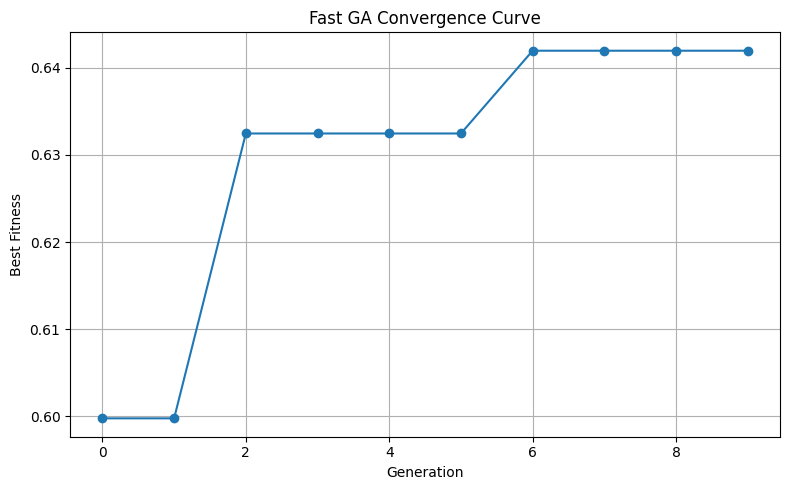

In [ ]:
# ===========================================
# ⚡ Ultra-Fast Genetic Algorithm (Smart Fitness Approximation v2)
# ===========================================

from google.colab import drive
drive.mount('/content/drive')

import numpy as np
import os, random, time, warnings
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from joblib import dump
from tqdm import trange
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

# ------------------ PATH CONFIG ------------------
BASE_DIR = "/content/drive/MyDrive/OTML_CT-1/eurosat_experiments/features"
OUT_DIR = os.path.join(BASE_DIR, "GA_Results_Ensemble_Fast")
os.makedirs(OUT_DIR, exist_ok=True)

feature_paths = [
    os.path.join(BASE_DIR, f"{m}_features.npy") for m in [
        "alexnet", "densenet121", "efficientnet_b0", "mobilenet_v2", "resnet50", "vgg16"
    ]
]
labels_path = os.path.join(BASE_DIR, "alexnet_labels.npy")

# ------------------ GA PARAMETERS -------------------
POP_SIZE = 10
N_GENERATIONS = 15
CROSSOVER_RATE = 0.8
ELITISM = 2
RANDOM_SEED = 42
PATIENCE = 4
GENERATION_TIME_LIMIT = 60  # seconds per generation (safety)

np.random.seed(RANDOM_SEED)
random.seed(RANDOM_SEED)

# ------------------ LOAD DATA ------------------
def load_concat_features(paths):
    feats = [np.load(p) for p in paths]
    X = np.concatenate(feats, axis=1)
    print(f"✅ Loaded {len(paths)} models' features. Final shape: {X.shape}")
    return X

# ------------------ GA HELPERS ------------------
def init_population(size, n_features):
    return [np.random.choice([0, 1], size=n_features).astype(np.uint8) for _ in range(size)]

def crossover(a, b):
    pt = random.randint(1, len(a) - 1)
    return np.concatenate((a[:pt], b[pt:])), np.concatenate((b[:pt], a[pt:]))

def mutate(ind, rate):
    mask = np.random.rand(len(ind)) < rate
    ind[mask] = 1 - ind[mask]
    return ind

def tournament(pop, fits, k=3):
    ids = np.random.choice(len(pop), k, replace=False)
    return pop[ids[np.argmax([fits[i] for i in ids])]].copy()

# ------------------ FASTER FITNESS FUNCTION ------------------
def fast_fitness(ind, X_train, X_test, y_train, y_test, clf):
    idx = np.where(ind == 1)[0]
    if len(idx) == 0:
        return 0.0

    # ⚡ Use only a small subset for evaluation (20%)
    sample_idx = np.random.choice(len(X_train), int(0.2 * len(X_train)), replace=False)
    Xtr, ytr = X_train[sample_idx][:, idx], y_train[sample_idx]
    Xte = X_test[:, idx]

    clf.fit(Xtr, ytr)
    preds = clf.predict(Xte)
    return accuracy_score(y_test, preds)

# ------------------ RUN GA ------------------
def run_ga(X, y):
    n_samples, n_features = X.shape
    print(f"⚙️ Running Fast GA on {n_features} features")

    # scale data and create one fixed split for speed
    X_scaled = StandardScaler().fit_transform(X)
    X_train, X_test, y_train, y_test = train_test_split(
        X_scaled, y, test_size=0.3, stratify=y, random_state=RANDOM_SEED
    )

    # optional downsample for speed
    X_train_small, _, y_train_small, _ = train_test_split(
        X_train, y_train, test_size=0.6, stratify=y_train, random_state=RANDOM_SEED
    )

    # ⚡ Lightweight classifier
    clf = DecisionTreeClassifier(max_depth=5, random_state=RANDOM_SEED)

    mut_rate = 1 / n_features
    pop = init_population(POP_SIZE, n_features)
    fitness_cache = {}
    history = []
    fits = []

    # Initial fitness
    for ind in pop:
        key = ind.tobytes()
        if key not in fitness_cache:
            fitness_cache[key] = fast_fitness(ind, X_train_small, X_test, y_train_small, y_test, clf)
        fits.append(fitness_cache[key])

    best = pop[np.argmax(fits)].copy()
    best_score = np.max(fits)
    no_improve = 0

    print(f"Initial fitness: {best_score:.4f}")

    for g in trange(N_GENERATIONS, desc="GA Progress"):
        start_time = time.time()
        history.append(best_score)

        new_pop = [pop[i].copy() for i in np.argsort(fits)[-ELITISM:]]
        while len(new_pop) < POP_SIZE:
            p1, p2 = tournament(pop, fits), tournament(pop, fits)
            if random.random() < CROSSOVER_RATE:
                c1, c2 = crossover(p1, p2)
            else:
                c1, c2 = p1, p2
            new_pop.append(mutate(c1, mut_rate))
            if len(new_pop) < POP_SIZE:
                new_pop.append(mutate(c2, mut_rate))

        pop = new_pop
        fits = []

        for ind in pop:
            key = ind.tobytes()
            if key not in fitness_cache:
                fitness_cache[key] = fast_fitness(ind, X_train_small, X_test, y_train_small, y_test, clf)
            fits.append(fitness_cache[key])

            # Safety break if generation takes too long
            if time.time() - start_time > GENERATION_TIME_LIMIT:
                print(f"⚠️ Generation {g+1} exceeded {GENERATION_TIME_LIMIT}s, skipping rest.")
                break

        gen_best = np.max(fits)
        if gen_best > best_score:
            best_score = gen_best
            best = pop[np.argmax(fits)].copy()
            no_improve = 0
        else:
            no_improve += 1

        print(f"Gen {g+1}/{N_GENERATIONS} | Best: {best_score:.4f} | No improve: {no_improve}")

        if no_improve >= PATIENCE:
            print(f"🛑 Early stopping: no improvement for {PATIENCE} generations")
            break

    selected = np.where(best == 1)[0]
    np.save(os.path.join(OUT_DIR, "selected_indices.npy"), selected)
    np.save(os.path.join(OUT_DIR, "ga_history.npy"), np.array(history))
    print(f"\n✅ Done. Best fitness: {best_score:.4f}, selected {len(selected)} features")
    return selected, X_scaled, history

# ------------------ FINAL EVALUATION ------------------
def evaluate_final(X_scaled, y, idx):
    Xs = X_scaled[:, idx]
    clf_rf = RandomForestClassifier(n_estimators=200, random_state=RANDOM_SEED)
    acc = np.mean(cross_val_score(clf_rf, Xs, y, cv=3, n_jobs=-1))
    print(f"\n🎯 Final Accuracy (RandomForest): {acc:.4f}")
    return acc

# ------------------ PLOT ------------------
def plot_ga_history(history):
    plt.figure(figsize=(8,5))
    plt.plot(history, marker='o')
    plt.title("Fast GA Convergence Curve")
    plt.xlabel("Generation")
    plt.ylabel("Best Fitness")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

# ------------------ MAIN ------------------
X = load_concat_features(feature_paths)
y = np.load(labels_path)

selected, X_scaled, hist = run_ga(X, y)
evaluate_final(X_scaled, y, selected)
plot_ga_history(hist)


In [ ]:
# ===========================================
# 🚀 Ultra-Fast ML Evaluation (Only SVM + Random Forest)
# ===========================================

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
import numpy as np
import os, warnings
warnings.filterwarnings("ignore")

# ------------------ PATH CONFIG ------------------
BASE_DIR = "/content/drive/MyDrive/OTML_CT-1/eurosat_experiments/features"
OUT_DIR = os.path.join(BASE_DIR, "GA_Results_Ensemble_Fast")
labels_path = os.path.join(BASE_DIR, "alexnet_labels.npy")

# ------------------ LOAD DATA ------------------
feature_paths = [
    os.path.join(BASE_DIR, f"{m}_features.npy") for m in [
        "alexnet", "densenet121", "efficientnet_b0",
        "mobilenet_v2", "resnet50", "vgg16"
    ]
]
feats = [np.load(p) for p in feature_paths]
X = np.concatenate(feats, axis=1)
y = np.load(labels_path)

# scale again
X_scaled = StandardScaler().fit_transform(X)

selected = np.load(os.path.join(OUT_DIR, "selected_indices.npy"))
print(f"✅ Loaded {len(selected)} GA-selected features for model evaluation.")
Xs = X_scaled[:, selected]

# ------------------ SPLIT DATA ------------------
X_train, X_test, y_train, y_test = train_test_split(
    Xs, y, test_size=0.3, stratify=y, random_state=42
)

# ------------------ MODEL 1: Linear SVM ------------------
svm_clf = LinearSVC(C=1.0, random_state=42, max_iter=2000)
svm_clf.fit(X_train, y_train)
svm_acc = accuracy_score(y_test, svm_clf.predict(X_test))
print(f"📊 Linear SVM Accuracy: {svm_acc:.4f}")

# ------------------ MODEL 2: Random Forest ------------------
rf_clf = RandomForestClassifier(
    n_estimators=100, max_depth=15, random_state=42, n_jobs=-1
)
rf_clf.fit(X_train, y_train)
rf_acc = accuracy_score(y_test, rf_clf.predict(X_test))
print(f"📊 Random Forest Accuracy: {rf_acc:.4f}")

# ------------------ Summary ------------------
print("\n=== 🏁 Model Comparison Summary (Single Split) ===")
print(f"Linear SVM     : {svm_acc:.4f}")
print(f"Random Forest  : {rf_acc:.4f}")


✅ Loaded 3248 GA-selected features for model evaluation.
📊 Linear SVM Accuracy: 0.9649
📊 Random Forest Accuracy: 0.9399

=== 🏁 Model Comparison Summary (Single Split) ===
Linear SVM     : 0.9649
Random Forest  : 0.9399


In [ ]:
# ===========================================
# ⚡ Logistic Regression (5-Fold CV + Single Split)
# ===========================================

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
import numpy as np, os, warnings
warnings.filterwarnings("ignore")

# ------------------ PATH CONFIG ------------------
BASE_DIR = "/content/drive/MyDrive/OTML_CT-1/eurosat_experiments/features"
OUT_DIR = os.path.join(BASE_DIR, "GA_Results_Ensemble_Fast")
labels_path = os.path.join(BASE_DIR, "alexnet_labels.npy")

# ------------------ LOAD & PREPARE DATA ------------------
feature_paths = [
    os.path.join(BASE_DIR, f"{m}_features.npy") for m in [
        "alexnet", "densenet121", "efficientnet_b0",
        "mobilenet_v2", "resnet50", "vgg16"
    ]
]
feats = [np.load(p) for p in feature_paths]
X = np.concatenate(feats, axis=1)
y = np.load(labels_path)

# Standardize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Load GA-selected indices
selected = np.load(os.path.join(OUT_DIR, "selected_indices.npy"))
Xs = X_scaled[:, selected]
print(f"✅ Loaded {len(selected)} GA-selected features for Logistic Regression.")

# ------------------ SPLIT DATA ------------------
X_train, X_test, y_train, y_test = train_test_split(
    Xs, y, test_size=0.3, stratify=y, random_state=42
)

# ------------------ MODEL: Logistic Regression ------------------
log_clf = LogisticRegression(
    C=1.0,
    solver='lbfgs',
    max_iter=2000,
    random_state=42,
    n_jobs=-1
)

# 5-Fold Cross Validation
cv_scores = cross_val_score(log_clf, Xs, y, cv=5, scoring='accuracy', n_jobs=-1)
log_cv_mean = np.mean(cv_scores)
log_cv_std = np.std(cv_scores)

print("\n📊 Logistic Regression (5-Fold CV) Accuracy:")
print(f"Mean: {log_cv_mean:.4f}  |  Std: ±{log_cv_std:.4f}")

# Single Split Accuracy
log_clf.fit(X_train, y_train)
log_acc = accuracy_score(y_test, log_clf.predict(X_test))
print(f"Single Split Accuracy: {log_acc:.4f}")
from sklearn.metrics import classification_report, confusion_matrix

# --- You already created this earlier ---
# X_train, X_test, y_train, y_test
# log_clf (trained Logistic Regression)

# Make predictions
y_pred = log_clf.predict(X_test)

# Print Classification Report
print("\n📋 Classification Report (Logistic Regression - GA Selected Features):")
print(classification_report(y_test, y_pred))

# Print Confusion Matrix
print("\n🔢 Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))


✅ Loaded 3248 GA-selected features for Logistic Regression.

📊 Logistic Regression (5-Fold CV) Accuracy:
Mean: 0.9761  |  Std: ±0.0016
Single Split Accuracy: 0.9736

📋 Classification Report (Logistic Regression - GA Selected Features):
              precision    recall  f1-score   support

           0       0.97      0.97      0.97       900
           1       0.99      0.99      0.99       900
           2       0.97      0.97      0.97       900
           3       0.96      0.95      0.96       750
           4       0.99      0.99      0.99       750
           5       0.96      0.96      0.96       600
           6       0.95      0.95      0.95       750
           7       0.99      0.99      0.99       900
           8       0.96      0.95      0.96       750
           9       1.00      0.99      0.99       900

    accuracy                           0.97      8100
   macro avg       0.97      0.97      0.97      8100
weighted avg       0.97      0.97      0.97      8100


🔢 Co